<a href="https://colab.research.google.com/github/SamakshNain/Brain-Tumor-Detection-and-Classification/blob/main/brain_tumor_detection_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### 📜 Table of Contents:
1. **Introduction**
   - Understanding Brain Tumor Types
   - Setting the Objectives

2. **Data Exploration and Augmentation**
   - Visualizing MRI Images
   - Preprocessing and Augmenting Data for Better Generalization

3. **Model Development**
   - Leveraging ResNet-101
   - Customizing for Brain Tumor Classification

4. **Training the Model**
   - Setting Hyperparameters
   - Fitting the Model to the Data

5. **Evaluation and Interpretation**
   - Analyzing Model Metrics
   - Visual Insights and Model Predictions

6. **Conclusion and Next Steps**
   - Recapitulating Key Takeaways
   - Proposing Directions for Future Work

---




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 1: Import Required Libraries


In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet101
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# Step 2: Define Paths and Directories


In [ ]:
# Paths to image directories
glioma_tumor_dir = '/content/drive/MyDrive/Data/glioma_tumor'
meningioma_tumor_dir = '/content/drive/MyDrive/Data/meningioma_tumor'
normal_dir = '/content/drive/MyDrive/Data/normal'
pituitary_tumor_dir = '/content/drive/MyDrive/Data/pituitary_tumor'

# Paths to training and validation directories
working_dir = '/content/drive/MyDrive/Data'
train_dir = os.path.join(working_dir, 'train')
val_dir = os.path.join(working_dir, 'val')

# Step 3: Exploratory Data Analysis (EDA)


## 3.1: Load and Display Sample Images


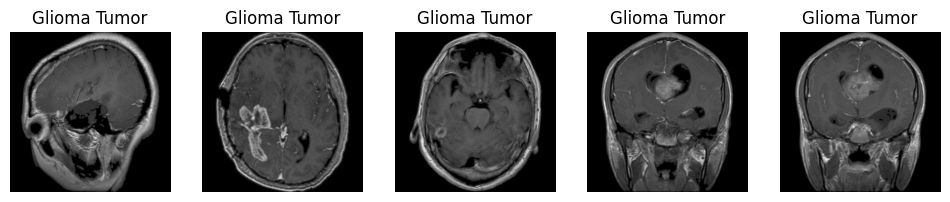

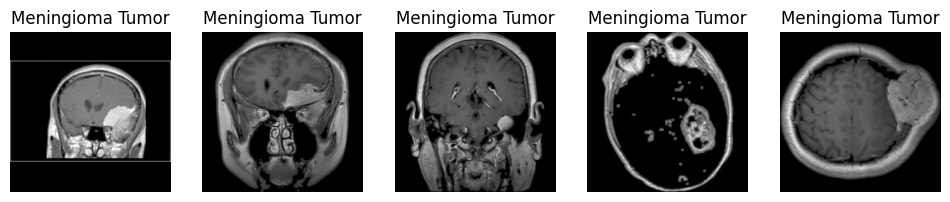

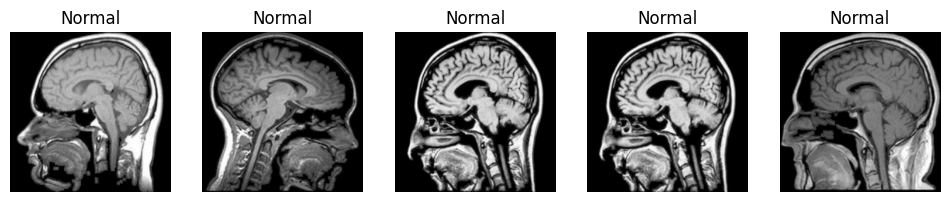

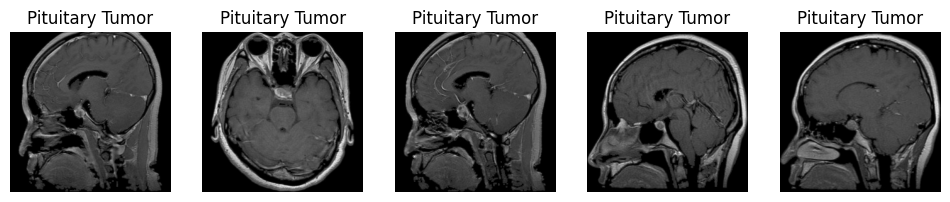

In [ ]:
def display_sample_images(image_dir, title, num_samples=5):
    plt.figure(figsize=(12, 4))
    image_paths = [os.path.join(image_dir, img) for img in os.listdir(image_dir)[:num_samples]]
    for i, image_path in enumerate(image_paths):
        img = mpimg.imread(image_path)
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

display_sample_images(glioma_tumor_dir, 'Glioma Tumor')
display_sample_images(meningioma_tumor_dir, 'Meningioma Tumor')
display_sample_images(normal_dir, 'Normal')
display_sample_images(pituitary_tumor_dir, 'Pituitary Tumor')

## 3.2: Display Dataset Distribution


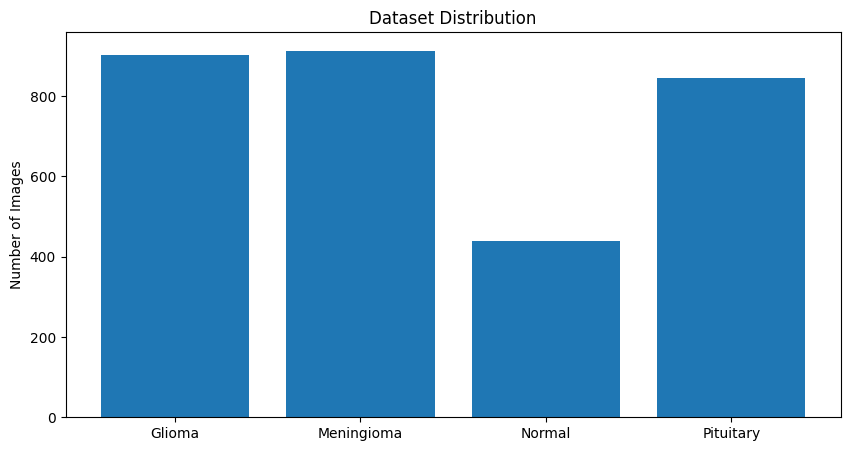

In [ ]:
def get_image_count(image_dir):
    return len([name for name in os.listdir(image_dir) if os.path.isfile(os.path.join(image_dir, name))])

glioma_count = get_image_count(glioma_tumor_dir)
meningioma_count = get_image_count(meningioma_tumor_dir)
normal_count = get_image_count(normal_dir)
pituitary_count = get_image_count(pituitary_tumor_dir)

plt.figure(figsize=(10, 5))
plt.bar(['Glioma', 'Meningioma', 'Normal', 'Pituitary'], [glioma_count, meningioma_count, normal_count, pituitary_count])
plt.ylabel('Number of Images')
plt.title('Dataset Distribution')
plt.show()

# Step 4: Organize Data into Training and Validation Sets


In [ ]:
def get_image_paths(directory_path):
    image_paths = []
    for root, dirs, files in os.walk(directory_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(root, file))
    return image_paths

def organize_data(image_paths, label, train_dir, val_dir, test_size=0.2):
    train_paths, val_paths = train_test_split(image_paths, test_size=test_size, random_state=42)
    def copy_images(paths, dest_dir):
        os.makedirs(dest_dir, exist_ok=True)
        for path in paths:
            shutil.copy(path, os.path.join(dest_dir, os.path.basename(path)))
    train_label_dir = os.path.join(train_dir, label)
    val_label_dir = os.path.join(val_dir, label)
    copy_images(train_paths, train_label_dir)
    copy_images(val_paths, val_label_dir)
    return len(train_paths), len(val_paths)

# Get image paths
glioma_image_paths = get_image_paths(glioma_tumor_dir)
meningioma_image_paths = get_image_paths(meningioma_tumor_dir)
normal_image_paths = get_image_paths(normal_dir)
pituitary_image_paths = get_image_paths(pituitary_tumor_dir)

# Organize data
num_train_glioma, num_val_glioma = organize_data(glioma_image_paths, 'glioma_tumor', train_dir, val_dir)
num_train_meningioma, num_val_meningioma = organize_data(meningioma_image_paths, 'meningioma_tumor', train_dir, val_dir)
num_train_normal, num_val_normal = organize_data(normal_image_paths, 'normal', train_dir, val_dir)
num_train_pituitary, num_val_pituitary = organize_data(pituitary_image_paths, 'pituitary_tumor', train_dir, val_dir)

# Step 5: Data Preprocessing


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet.preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 2475 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


# Step 6: Build and Compile the Model


In [ ]:
model = models.Sequential()
model.add(ResNet101(include_top=False, weights='imagenet', pooling='avg'))
model.add(layers.Dense(4, activation='softmax'))

for layer in model.layers[0].layers:
    layer.trainable = False

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 7: Train the Model


In [ ]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 53s 626ms/step - accuracy: 0.8805 - loss: 0.3257 - val_accuracy: 0.8712 - val_loss: 0.3446
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 51s 605ms/step - accuracy: 0.8712 - loss: 0.3397 - val_accuracy: 0.8663 - val_loss: 0.3509
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 82s 605ms/step - accuracy: 0.8911 - loss: 0.3099 - val_accuracy: 0.8873 - val_loss: 0.3236
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 82s 598ms/step - accuracy: 0.8945 - loss: 0.2913 - val_accuracy: 0.8712 - val_loss: 0.3348
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 51s 614ms/step - accuracy: 0.8887 - loss: 0.2956 - val_accuracy: 0.8857 - val_loss: 0.3185
Epoch 6/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 51s 590ms/step - accuracy: 0.8834 - loss: 0.3173 - val_accuracy: 0.8454 - val_loss: 0.3778
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 83s 603ms/step - accuracy: 0.8934 - loss: 0.3098 - val_accuracy: 0.8631 - val_loss: 0.3318
Epoch 8/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 52s 622ms/step - accuracy: 0.8936 - loss: 0.2862 - val_accu

# Step 8: Evaluate the Model and Plot Results

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.9009 - loss: 0.2711
Validation Accuracy: 0.8953301310539246


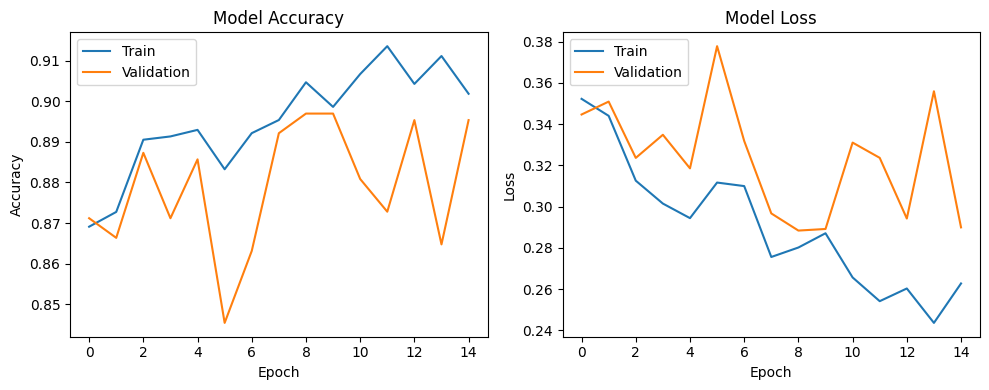

In [ ]:
# Evaluate the model on validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print("Validation Accuracy: {}".format(val_accuracy))

# Plot training & validation accuracy values
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()